In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


In [54]:
# link to csv files
data_dir = "C:\\Users\\ben\\OneDrive - University of South Carolina\\teaching\\GEOG202-F26\\activities\\us-temperatures"

augusta_me = pd.read_csv(f"{data_dir}/augusta-me.csv")
charleston_sc = pd.read_csv(f"{data_dir}/charleston-sc.csv")
chicago_il = pd.read_csv(f"{data_dir}/chicago-il.csv")
dfw_tx = pd.read_csv(f"{data_dir}/dfw-tx.csv")
grandforks_nd = pd.read_csv(f"{data_dir}/grandforks-nd.csv")
leadville_co = pd.read_csv(f"{data_dir}/leadville-co.csv")
lincoln_ne = pd.read_csv(f"{data_dir}/lincoln-ne.csv")
madison_wi = pd.read_csv(f"{data_dir}/madison-wi.csv")
miami_fl = pd.read_csv(f"{data_dir}/miami-fl.csv")
nyc_ny = pd.read_csv(f"{data_dir}/nyc-ny.csv")
sandiego_ca = pd.read_csv(f"{data_dir}/sandiego-ca.csv")
seattle_wa = pd.read_csv(f"{data_dir}/seattle-wa.csv")


In [55]:
cities = {
    "Augusta, ME": augusta_me,
    "Charleston, SC": charleston_sc,
    "Chicago, IL": chicago_il,
    "Dallas-Fort Worth, TX": dfw_tx,
    "Grand Forks, ND": grandforks_nd,
    "Leadville, CO": leadville_co,
    "Lincoln, NE": lincoln_ne,
    "Madison, WI": madison_wi,
    "Miami, FL": miami_fl,
    "New York City, NY": nyc_ny,
    "San Diego, CA": sandiego_ca,
    "Seattle, WA": seattle_wa
}

In [56]:
cities['Augusta, ME'].head()

,STATION,DATE,MLY-PRCP-NORMAL,MLY-SNOW-NORMAL,MLY-TAVG-NORMAL,MLY-TMAX-NORMAL,MLY-TMIN-NORMAL
0,USW00014605,1,2.62,NaN,20.4,28.8,12.1
1,USW00014605,2,2.32,NaN,23.2,31.9,14.4
2,USW00014605,3,3.21,NaN,32.0,40.6,23.4
3,USW00014605,4,3.82,NaN,43.8,53.5,34.2
4,USW00014605,5,3.27,NaN,55.3,65.8,44.7


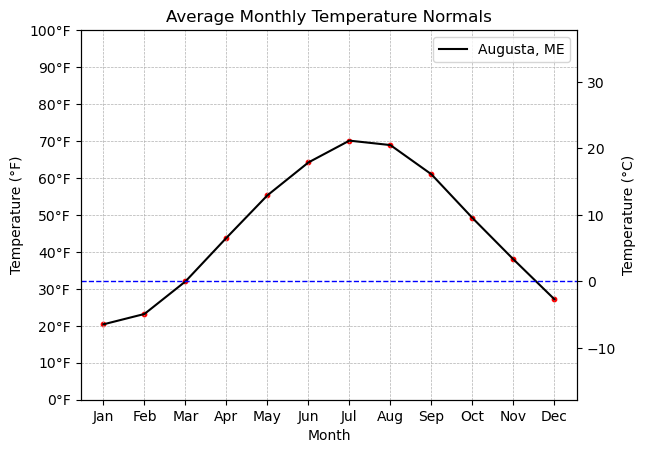

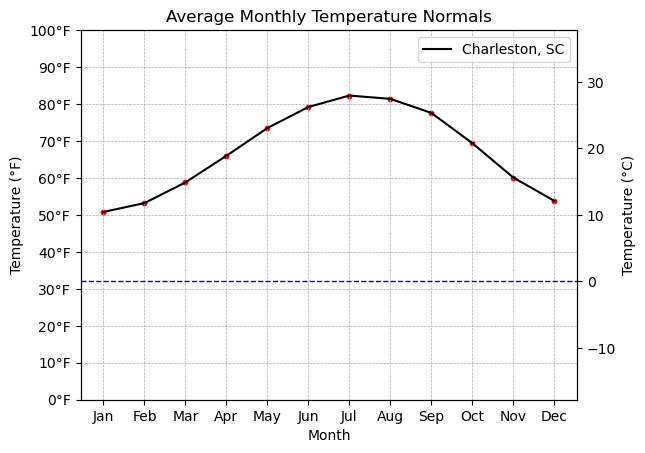

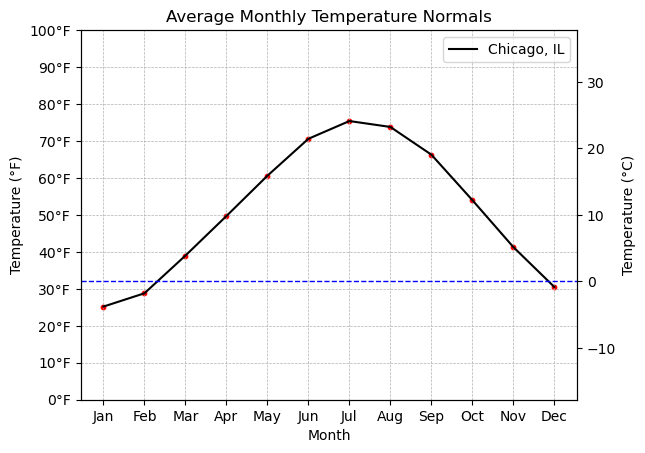

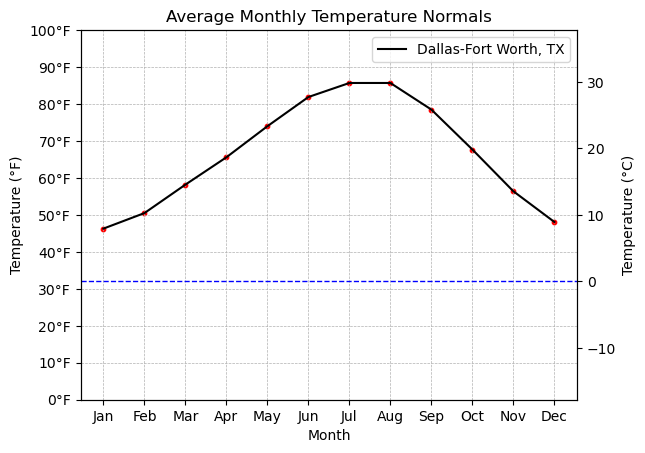

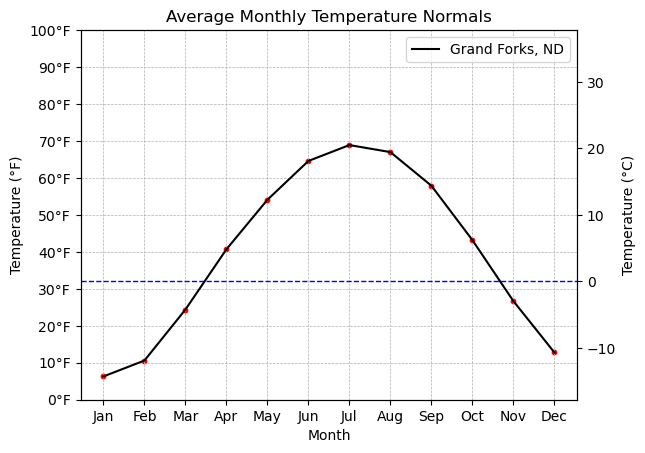

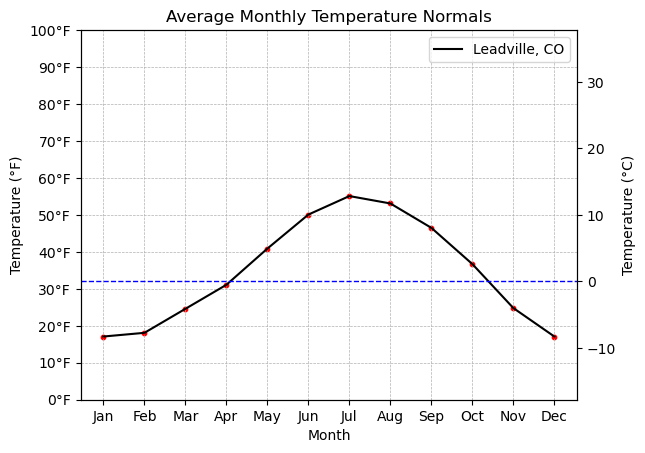

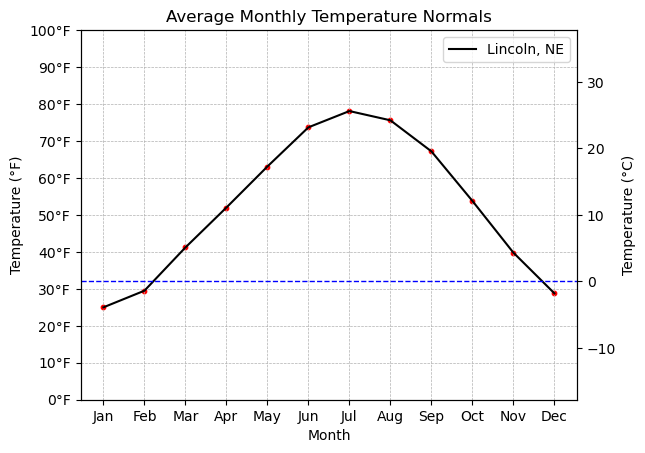

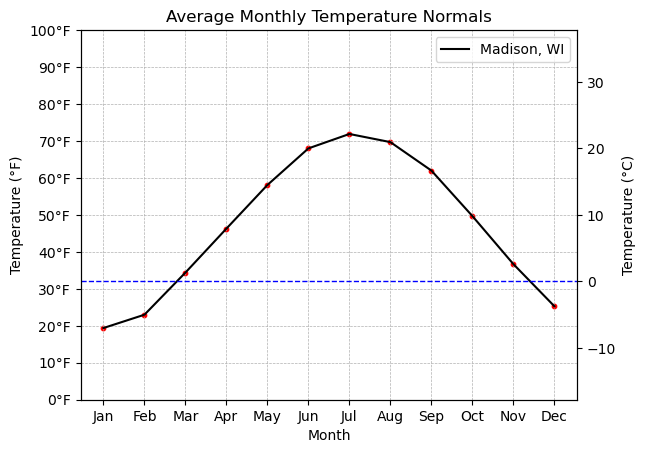

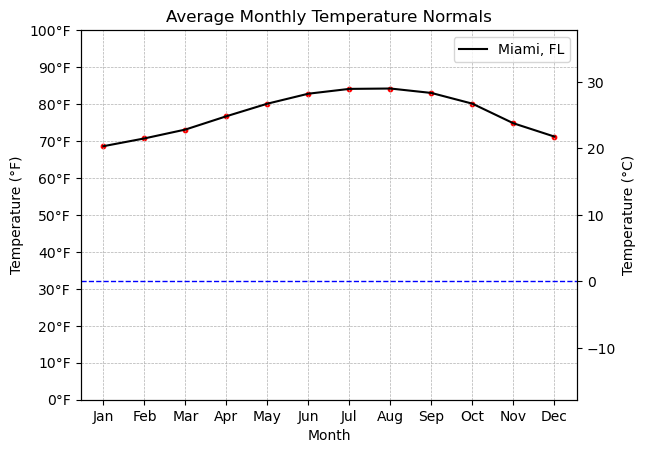

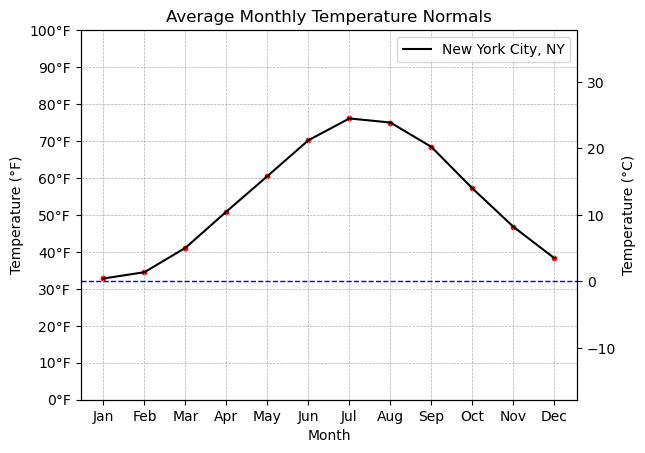

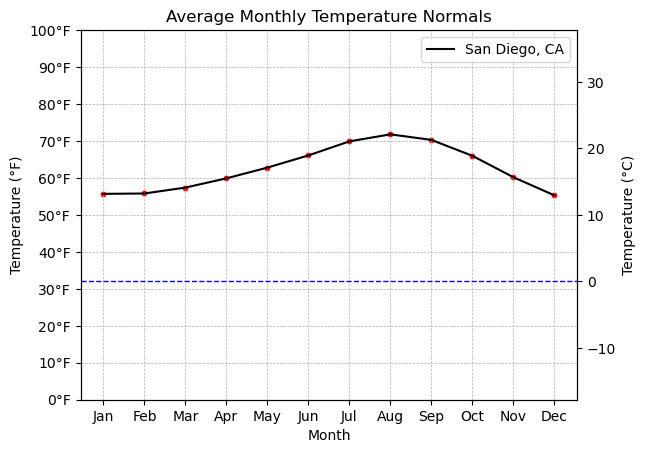

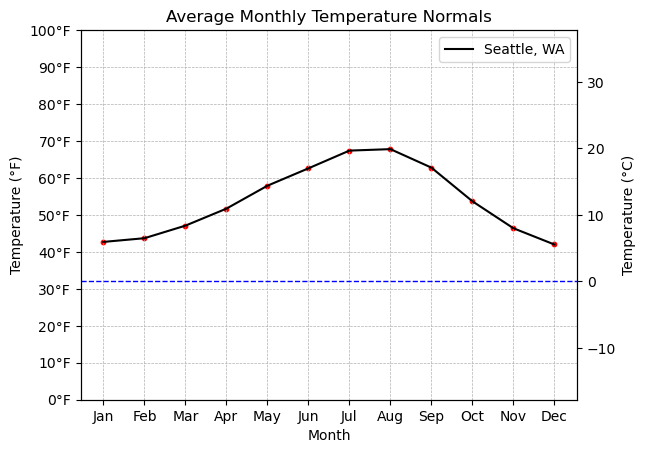

In [68]:
Path("labled_plots").mkdir(parents=True, exist_ok=True)
Path("blank_plots").mkdir(parents=True, exist_ok=True)


for city, df in cities.items():
    fig, ax1 = plt.subplots()
    ax1.plot(df['DATE'], df['MLY-TAVG-NORMAL'], label=city, color='black')
    ax1.scatter(df['DATE'], df['MLY-TAVG-NORMAL'], color='red', s=10)  # Add scatter points for clarity

    ax1.set_title('Average Monthly Temperature Normals')
    ax1.set_xlabel('Month')
    ax1.set_ylabel('Temperature (°F)')
    ax1.set_ylim(0, 100)  # Set Fahrenheit limits
    # label every 10 degrees f
    ax1.set_yticks(np.arange(0, 101, 10))
    ax1.set_yticklabels([f'{i}°F' for i in np.arange(0, 101, 10)])
    ax1.grid(True, which='both', linestyle='--', linewidth=0.5)

    # Convert x-axis to month names
    ax1.set_xticks(np.arange(1, 13))
    ax1.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
    ax1.legend()

    # Create the alternate y-axis for Celsius
    ax2 = ax1.twinx()
    ax2.set_ylabel('Temperature (°C)')

    # Align the Celsius limits perfectly with the Fahrenheit limits
    f_min, f_max = ax1.get_ylim()
    c_min = (f_min - 32) * 5 / 9
    c_max = (f_max - 32) * 5 / 9
    ax2.set_ylim(c_min, c_max)

    # horizontal line at freezing point
    ax1.axhline(y=32, color='blue', linestyle='--', linewidth=1, label='Freezing Point (32°F)')

    

    # plt.show()
    plt.savefig(f'labled_plots/{city}_temperature_normals.png')


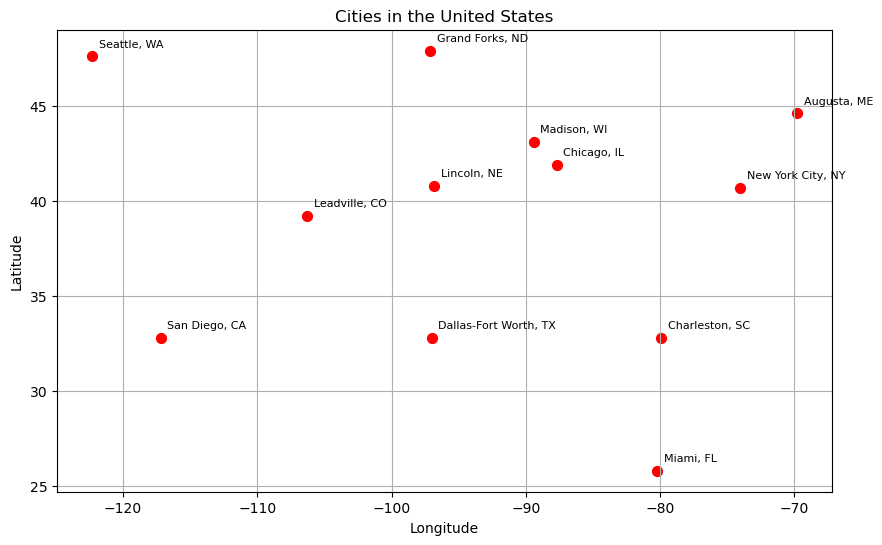

In [59]:
# create a us map of all the cities with a dot for each city and the name of the city next to it
import matplotlib.pyplot as plt

# Sample coordinates for each city (replace with actual coordinates)
city_coordinates = {
    "Augusta, ME": (-69.8, 44.6),
    "Charleston, SC": (-79.9, 32.8),
    "Chicago, IL": (-87.7, 41.9),
    "Dallas-Fort Worth, TX": (-97.0, 32.8),
    "Grand Forks, ND": (-97.1, 47.9),
    "Leadville, CO": (-106.3, 39.2),
    "Lincoln, NE": (-96.8, 40.8),
    "Madison, WI": (-89.4, 43.1),
    "Miami, FL": (-80.2, 25.8),
    "New York City, NY": (-74.0, 40.7),
    "San Diego, CA": (-117.2, 32.8),
    "Seattle, WA": (-122.3, 47.6)
}

# Create the map
plt.figure(figsize=(10, 6))
for city, (lon, lat) in city_coordinates.items():
    plt.scatter(lon, lat, color='red', s=50)
    plt.text(lon + 0.5, lat + 0.5, city, fontsize=8)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Cities in the United States')
plt.grid(True)
plt.show()